# Análise das Temperaturas Máximas Médias do Brasil — INMET 1991-2020

## Objetivo

Analisar a distribuição das temperaturas máximas médias no Brasil a partir das Normais Climatológicas do INMET para o período de 1991–2020, explorando diferenças entre meses, estados, regiões e estações meteorológicas.

## 📚 Fonte dos dados

**Fonte:** Instituto Nacional de Meteorologia (INMET) — Normais Climatológicas do Brasil 1991–2020.

Os dados utilizados neste projeto correspondem às temperaturas máximas médias das estações meteorológicas brasileiras no período de 1991 a 2020.

🔗 [INMET — Normais Climatológicas](https://portal.inmet.gov.br/normais)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Normal-Climatologica-TMAX.xlsx to Normal-Climatologica-TMAX (2).xlsx


In [3]:
df = pd.read_excel(next(iter(uploaded)), header=2)

In [4]:
df.head()

,Código,Nome da Estação,UF,Janeiro,Fevereiro,Março,Abril,Maio,Junho,Julho,Agosto,Setembro,Outubro,Novembro,Dezembro,Ano
0,83249,ALAGOINHAS,BA,26.4,26.4,26.5,25.5,24.2,22.9,22,22,23,24.3,25.5,26.2,24.6
1,82970,ALTO PARNAIBA,MA,26,25.9,26.1,26.3,26.1,25,24.7,25.8,27.9,28.3,27.1,26.4,26.3
2,83096,ARACAJU,SE,27.3,27.5,27.7,27.3,26.5,25.6,24.9,24.9,25.4,26.2,26.7,27.1,26.4
3,83442,ARACUAI,MG,26.7,27.2,26.7,25.7,23.8,22.5,22.2,23.5,25.5,26.9,26.1,26.2,25.3
4,83368,ARAGARCAS,GO,26.2,26.2,26.3,26.4,24.8,23.6,23.4,25.7,28,28.3,26.8,26.3,26


In [5]:
df.shape

(146, 16)

## 1. Importação dos dados

Os dados utilizados neste projeto foram obtidos a partir das Normais Climatológicas do Instituto Nacional de Meteorologia (INMET), referentes ao período de 1991–2020.

A base contém informações de temperatura máxima média compensada mensal e anual de estações meteorológicas brasileiras.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Código           146 non-null    int64  
 1   Nome da Estação  146 non-null    object 
 2   UF               146 non-null    object 
 3   Janeiro          146 non-null    object 
 4   Fevereiro        146 non-null    object 
 5   Março            146 non-null    object 
 6   Abril            146 non-null    object 
 7   Maio             146 non-null    object 
 8   Junho            146 non-null    object 
 9   Julho            146 non-null    object 
 10  Agosto           146 non-null    object 
 11  Setembro         146 non-null    object 
 12  Outubro          146 non-null    object 
 13  Novembro         146 non-null    float64
 14  Dezembro         146 non-null    object 
 15  Ano              146 non-null    object 
dtypes: float64(1), int64(1), object(14)
memory usage: 18.4+ KB


## 2. Limpeza e tratamento dos dados

Nesta etapa, os dados serão verificados e tratados para garantir que as informações estejam em formato adequado para a análise. Serão tratados valores ausentes, realizada a conversão das temperaturas para formato numérico e verificadas possíveis duplicidades.

In [7]:
df.isna().sum()

,0
Código,0
Nome da Estação,0
UF,0
Janeiro,0
Fevereiro,0
Março,0
Abril,0
Maio,0
Junho,0
Julho,0


In [8]:
df.isin(["-"]).sum()

,0
Código,0
Nome da Estação,0
UF,0
Janeiro,13
Fevereiro,2
Março,3
Abril,3
Maio,2
Junho,4
Julho,8


In [9]:
df = df.replace("-", pd.NA)

In [10]:
meses = ["Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho",
         "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro", "Ano"]

df[meses] = df[meses].apply(pd.to_numeric, errors="coerce")

In [11]:
df.dtypes

,0
Código,int64
Nome da Estação,object
UF,object
Janeiro,float64
Fevereiro,float64
Março,float64
Abril,float64
Maio,float64
Junho,float64
Julho,float64


In [12]:
df.isna().sum()

,0
Código,0
Nome da Estação,0
UF,0
Janeiro,13
Fevereiro,2
Março,3
Abril,3
Maio,2
Junho,4
Julho,8


In [13]:
df.columns = df.columns.str.strip()

In [14]:
df = df.rename(columns={"Ano": "Temp_Media_Anual"})

In [15]:
df["Código"].duplicated().sum()

np.int64(0)

In [16]:
df["Nome da Estação"].duplicated().sum()

np.int64(0)

## 3. Análise exploratória

Nesta etapa, foram analisadas as temperaturas médias das estações meteorológicas sob diferentes perspectivas, considerando a variação mensal, as diferenças entre estados e regiões e os extremos de temperatura registrados na base.

### 3.1 Temperatura máxima média por mês

A temperatura máxima média foi calculada para cada mês, considerando as temperaturas disponíveis nas estações meteorológicas da base. A análise permite observar como a temperatura máxima média varia ao longo do ano.

In [17]:
df_mensal = df.melt(
    id_vars=["Código", "Nome da Estação", "UF"],
    value_vars=["Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho",
                "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"],
    var_name="Mês",
    value_name="Temperatura"
)

In [18]:
media_mensal = df_mensal.groupby("Mês")["Temperatura"].mean()

In [19]:
media_mensal

,Temperatura
Mês,
Abril,24.124476
Agosto,22.600699
Dezembro,25.257639
Fevereiro,25.222222
Janeiro,25.191729
Julho,21.329710
Junho,21.707042
Maio,22.715972
Março,24.853846


In [20]:
ordem_meses = ["Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho",
               "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"]

media_mensal = media_mensal.reindex(ordem_meses)

In [21]:
media_mensal

,Temperatura
Mês,
Janeiro,25.191729
Fevereiro,25.222222
Março,24.853846
Abril,24.124476
Maio,22.715972
Junho,21.707042
Julho,21.329710
Agosto,22.600699
Setembro,23.838732


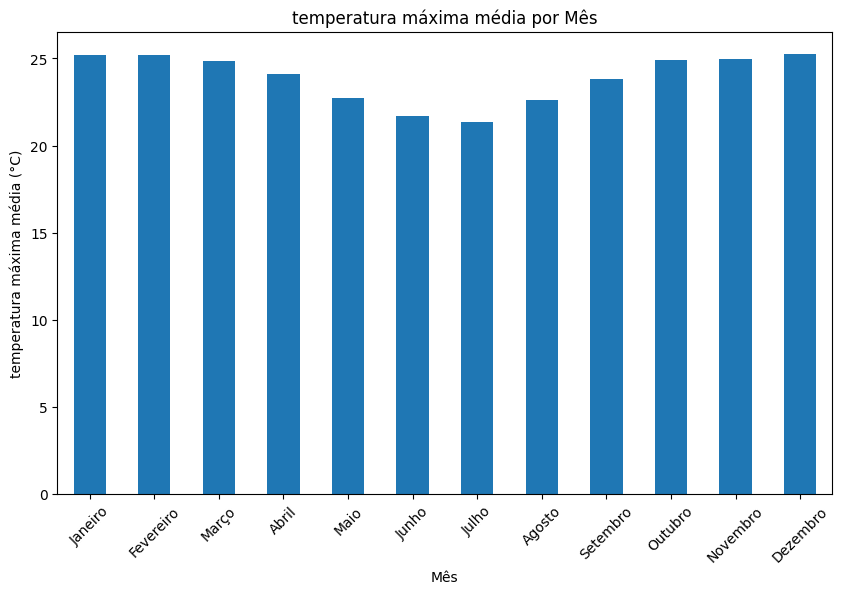

In [22]:
media_mensal.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("temperatura máxima média por Mês")
plt.xlabel("Mês")
plt.ylabel("temperatura máxima média (°C)")
plt.xticks(rotation=45)
plt.show()

### 3.2 Temperatura máxima média por estado

Foi calculada a temperatura máxima média das estações para cada estado, permitindo comparar as médias de temperatura entre as diferentes unidades federativas representadas na base.

In [23]:
media_uf = df_mensal.groupby("UF")["Temperatura"].mean().sort_values(ascending=False)

In [24]:
media_uf

,Temperatura
UF,
RR,28.209091
PI,27.800000
AP,27.400000
PA,27.140625
MA,26.995745
PB,26.983333
AM,26.858333
RN,26.674286
TO,26.251667


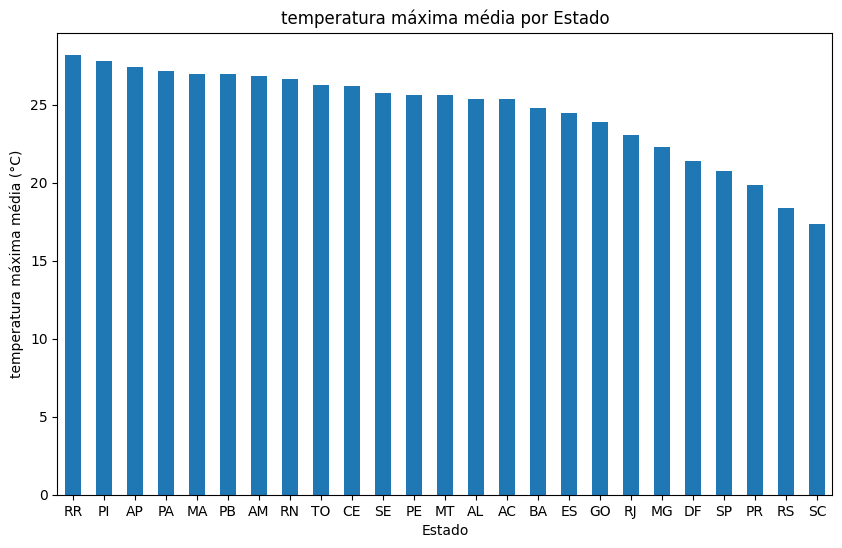

In [25]:
media_uf.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("temperatura máxima média por Estado")
plt.xlabel("Estado")
plt.ylabel("temperatura máxima média (°C)")
plt.xticks(rotation=0)
plt.show()

### 3.2.1 Mapa de temperatura máxima média por estado

O mapa apresenta a temperatura máxima média das estações meteorológicas por unidade federativa, permitindo visualizar espacialmente as diferenças de temperatura entre os estados.

In [26]:
!pip -q install geobr

/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
states_2020_simplified.parquet: 100%|██████████| 1.72M/1.72M [00:00<00:00, 26.4MB/s]


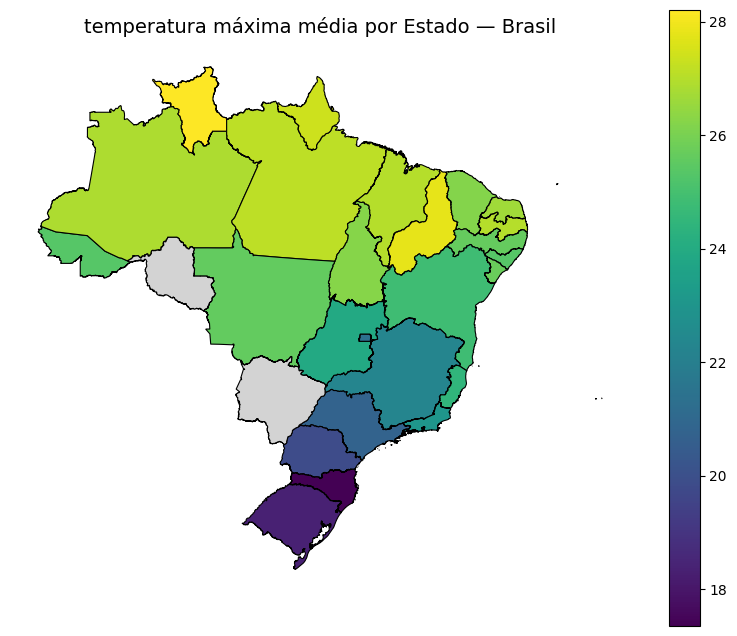

In [27]:
import geobr
import matplotlib.pyplot as plt

# Carrega os limites dos estados brasileiros
estados = geobr.read_state(year=2020)

# Transforma as médias por estado em DataFrame
mapa_temp = media_uf.rename("Temperatura_Media").reset_index()

# Renomeia a coluna da UF
mapa_temp = mapa_temp.rename(columns={"UF": "abbrev_state"})

# Junta as temperaturas ao mapa dos estados
estados = estados.merge(
    mapa_temp,
    on="abbrev_state",
    how="left"
)

# Cria o mapa
fig, ax = plt.subplots(figsize=(10, 8))

estados.plot(
    column="Temperatura_Media",
    legend=True,
    linewidth=0.8,
    edgecolor="black",
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sem dados"
    }

)

ax.set_title("temperatura máxima média por Estado — Brasil", fontsize=14)
ax.axis("off")

plt.show()

### 3.3 Temperatura máxima média por região

A temperatura máxima média foi calculada para cada região do Brasil a partir das estações meteorológicas representadas na base. Essa análise permite comparar o comportamento das temperaturas entre as diferentes regiões.

In [28]:
regioes = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte",
    "RO": "Norte", "RR": "Norte", "TO": "Norte",
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste",
    "MA": "Nordeste", "PB": "Nordeste", "PE": "Nordeste",
    "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
    "DF": "Centro-Oeste", "GO": "Centro-Oeste",
    "MT": "Centro-Oeste", "MS": "Centro-Oeste",
    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul"
}

df_mensal["Região"] = df_mensal["UF"].map(regioes)

In [29]:
media_regiao = df_mensal.groupby("Região")["Temperatura"].mean().sort_values(ascending=False)

In [30]:
media_regiao

,Temperatura
Região,
Norte,26.874823
Nordeste,26.115315
Centro-Oeste,24.273563
Sudeste,22.408983
Sul,18.392674


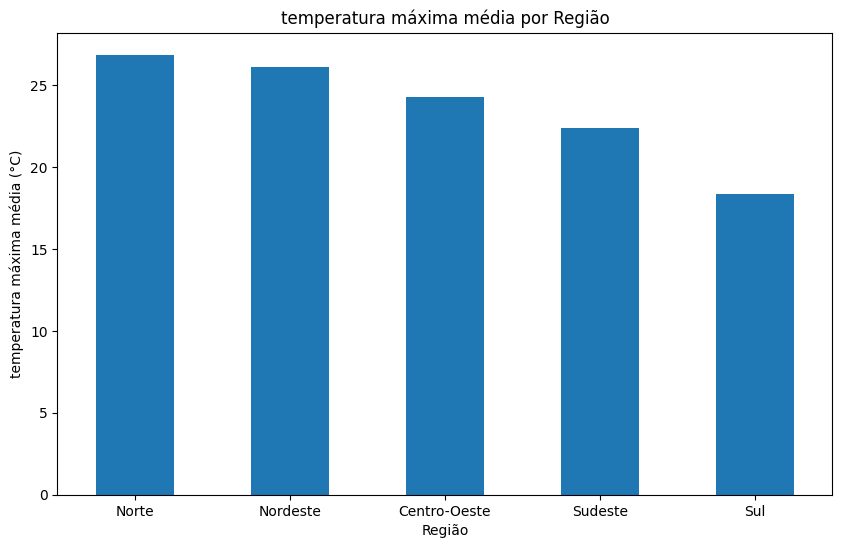

In [31]:
media_regiao.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("temperatura máxima média por Região")
plt.xlabel("Região")
plt.ylabel("temperatura máxima média (°C)")
plt.xticks(rotation=0)
plt.show()

### 3.4 Estações com maiores temperaturas máximas médias anuais

Foram identificadas as estações meteorológicas com os maiores valores de temperatura máxima média anual disponíveis na base, permitindo destacar os locais que apresentaram as maiores médias no período analisado.

In [32]:
maiores_estacoes = df[
    ["Código", "Nome da Estação", "UF", "Temp_Media_Anual"]
].dropna(subset=["Temp_Media_Anual"]).sort_values(
    "Temp_Media_Anual",
    ascending=False
).head(10)

maiores_estacoes

,Código,Nome da Estação,UF,Temp_Media_Anual
55,82678,FLORIANO,PI,28.3
126,82879,SAO JOAO DO PIAUI,PI,27.9
72,82493,JAGUARUANA,CE,27.7
86,82562,MARABA,PA,27.6
69,82445,ITAITUBA,PA,27.6
29,82263,CAMETA,PA,27.5
49,82693,CRUZETA,RN,27.5
109,82480,PIRIPIRI,PI,27.5
82,82098,MACAPA,AP,27.4
85,82331,MANAUS,AM,27.4


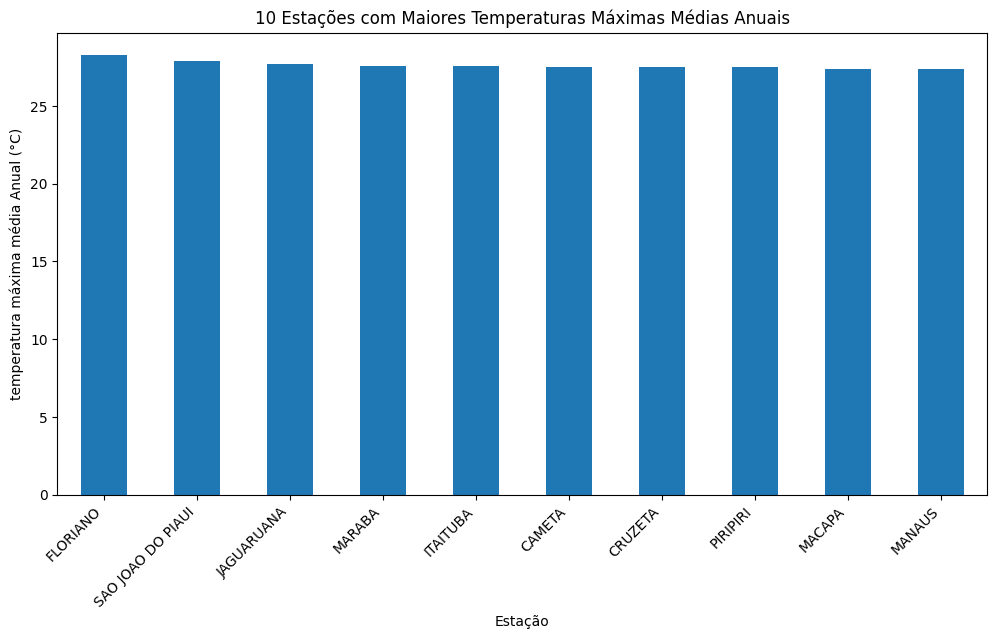

In [33]:
maiores_estacoes.plot(
    x="Nome da Estação",
    y="Temp_Media_Anual",
    kind="bar",
    figsize=(12, 6),
    legend=False
)

plt.title("10 Estações com Maiores Temperaturas Máximas Médias Anuais")
plt.xlabel("Estação")
plt.ylabel("temperatura máxima média Anual (°C)")
plt.xticks(rotation=45, ha="right")
plt.show()

### 3.5 Estações com menores temperaturas máximas médias anuais

Foram identificadas as estações meteorológicas com os menores valores de temperatura máxima média anual disponíveis na base, permitindo destacar os locais que apresentaram as menores médias no período analisado.

In [34]:
menores_estacoes = df[
    ["Código", "Nome da Estação", "UF", "Temp_Media_Anual"]
].dropna(subset=["Temp_Media_Anual"]).sort_values(
    "Temp_Media_Anual",
    ascending=True
).head(10)

menores_estacoes

,Código,Nome da Estação,UF,Temp_Media_Anual
127,83920,SAO JOAQUIM,SC,13.5
23,83919,BOM JESUS,RS,15.2
78,83891,LAGES,SC,16.1
31,83887,CAMPOS NOVOS,SC,16.7
123,83997,SANTA VITORIA DO PALMAR,RS,17.1
66,83836,IRATI,PR,17.5
54,83964,ENCRUZILHADA DO SUL,RS,17.6
51,83842,CURITIBA,PR,17.8
101,83914,PASSO FUNDO,RS,17.8
10,83980,BAGE,RS,17.9


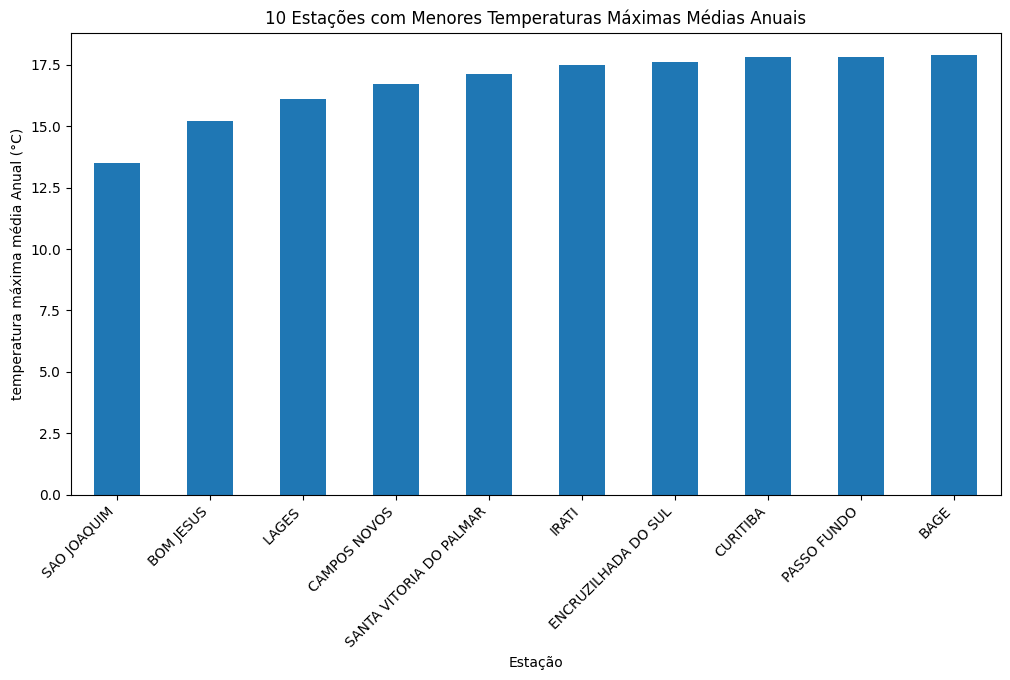

In [35]:
menores_estacoes.plot(
    x="Nome da Estação",
    y="Temp_Media_Anual",
    kind="bar",
    figsize=(12, 6),
    legend=False
)

plt.title("10 Estações com Menores Temperaturas Máximas Médias Anuais")
plt.xlabel("Estação")
plt.ylabel("temperatura máxima média Anual (°C)")
plt.xticks(rotation=45, ha="right")
plt.show()

### 3.6 Distribuição das temperaturas máximas médias anuais

Foi analisada a distribuição das temperaturas máximas médias anuais das estações com dados disponíveis, buscando identificar a concentração dos valores e a amplitude observada na base.

In [36]:
df["Temp_Media_Anual"].describe()

,Temp_Media_Anual
count,110.000000
mean,23.600909
std,3.432134
min,13.500000
25%,20.950000
50%,24.450000
75%,26.575000
max,28.300000


Algumas estações não possuem temperatura máxima média anual informada, por isso essas análises consideram apenas as estações com dados disponíveis.

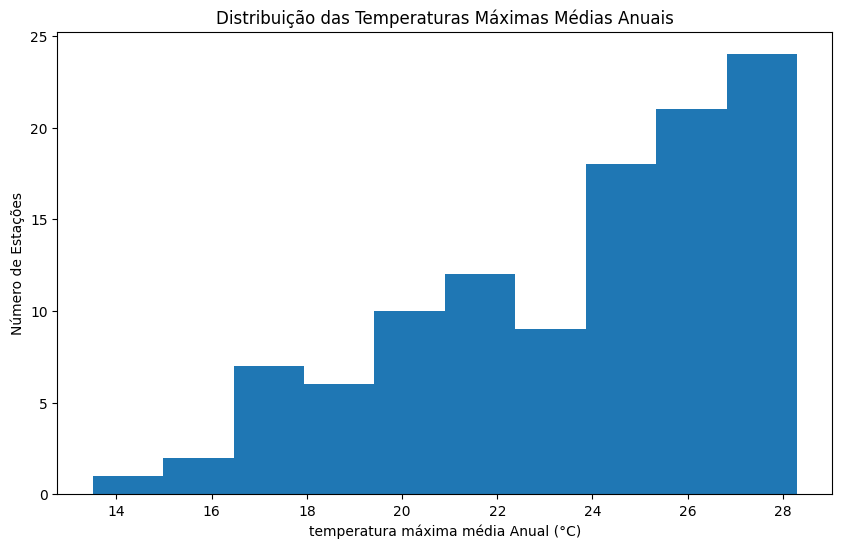

In [37]:
df["Temp_Media_Anual"].plot(
    kind="hist",
    bins=10,
    figsize=(10, 6)
)

plt.title("Distribuição das Temperaturas Máximas Médias Anuais")
plt.xlabel("temperatura máxima média Anual (°C)")
plt.ylabel("Número de Estações")
plt.show()

In [38]:
amplitude = df["Temp_Media_Anual"].max() - df["Temp_Media_Anual"].min()
amplitude

14.8

## 4. Principais insights

A análise das Normais Climatológicas do INMET permitiu identificar diferenças nas temperaturas máximas médias entre meses, estados, regiões e estações meteorológicas.

Entre os principais resultados, destacam-se:

- As temperaturas máximas médias mensais foram mais elevadas no verão, com dezembro apresentando a maior média, enquanto julho apresentou a menor.
- Entre os estados representados na base, Roraima apresentou a maior temperatura máxima média, enquanto Santa Catarina apresentou a menor.
- Na comparação entre regiões, o Norte apresentou a maior temperatura máxima média, seguido pelo Nordeste, Centro-Oeste, Sudeste e Sul.
- Entre as estações com temperatura máxima média anual disponível, Floriano (PI) apresentou o maior valor, com 28,3 °C.
- São Joaquim (SC) apresentou o menor valor de temperatura máxima média anual, com 13,5 °C.
- A temperatura máxima média anual apresentou uma amplitude de 14,8 °C entre o menor e o maior valor observado.

## 5. Conclusão

A análise das Normais Climatológicas do INMET permitiu observar diferenças relevantes nas temperaturas máximas médias entre as estações meteorológicas brasileiras. Os resultados mostraram um padrão de temperaturas mais elevadas nas regiões Norte e Nordeste e menores temperaturas na região Sul.

A análise também permitiu identificar os meses, estados e estações que apresentaram os maiores e menores valores de temperatura máxima média, proporcionando uma visão geral do comportamento climático observado na base.

O projeto demonstra como ferramentas de análise de dados, como Python e Pandas, podem ser utilizadas para organizar, explorar e interpretar dados climáticos reais.